# Relatório do Laboratório 3 — Alinhamento, Homografia 2D e Mosaico

### ESZA019 — Visão Computacional · UFABC · 2026.2

---

**Autores:**

| # | Nome completo | RA |
|---|---------------|----|
| 1 | *Antonio Carlos de Freitas Vidal Junior* | *11201920894* |
| 2 | *João Vitor De Oliveira Lamano* | *11202022114* |
| 3 | *Willian Kenji Takaracy* | *11201812251* |


## 1. Introdução

Neste terceiro laboratório de Visão Computacional, demos sequência ao estudo de
características (*features*) iniciado no Lab 2 e avançamos para o **alinhamento de
imagens**: o problema de descobrir a transformação geométrica que leva uma imagem
a se "encaixar" sobre outra. Quando duas fotos mostram o mesmo plano (uma mesa, a
capa de um livro, o chão) a partir de pontos de vista um pouco diferentes, essa
transformação é descrita por uma matriz chamada **homografia 2D**.

A partir dela, conseguimos **projetar** uma imagem no plano da outra e **costurar**
as duas em uma imagem maior — é o chamado *image stitching*, a mesma ideia usada
para montar panoramas no celular. Mas há um detalhe importante: o casamento de
pontos entre as imagens quase sempre produz **erros (outliers)**, e um único
casamento errado é capaz de estragar todo o cálculo se usarmos o método
tradicional de mínimos quadrados. Por isso, este laboratório compara dois
caminhos para estimar a homografia: o **Mínimos Quadrados clássico** (que usa
todos os pontos, inclusive os errados) e o **RANSAC** (que filtra os erros de
forma robusta).

O relatório segue a estrutura: primeiro a **fundamentação teórica** (homografia,
mínimos quadrados × RANSAC e o pipeline de mosaico); depois os **procedimentos
experimentais**, em que capturamos pares de imagens com **duas webcams** em dois
cenários — (A.1) uma **pessoa** e (A.2) um **livro** — e construímos os mosaicos,
além de uma versão (B) que faz a **sobreposição em tempo real** quadro a quadro; e
por fim a **análise e discussão**, que inclui as questões quantitativas pedidas no
roteiro (porcentagem de outliers, comparação das matrizes, número mínimo de pontos
e artefatos de costura) e uma reflexão sobre o uso dessas técnicas no trabalho
final.


## 2. Fundamentação Teórica

### 2.1 Correspondência de características e o teste de Lowe

O ponto de partida do alinhamento é encontrar **pontos correspondentes** entre as
duas imagens. Para isso usamos o detector **SIFT** (*Scale-Invariant Feature
Transform*), que localiza pontos-chave robustos a escala e rotação e descreve cada
um por um vetor de 128 números. Em seguida, casamos esses descritores com um
*matcher* — neste laboratório usamos o **força bruta** (`cv2.BFMatcher`) pedindo os
**dois vizinhos mais próximos** de cada ponto (`knnMatch(..., k=2)`).

Nem todo casamento é confiável, então aplicamos o **teste da razão de Lowe**:
mantemos um par apenas quando o melhor vizinho é bem mais próximo que o segundo
(no código, `m.distance < 0.75 * n.distance`). Isso já elimina boa parte dos
casamentos ambíguos — mas, como veremos, **ainda sobram erros**, e é aí que entra
a robustez geométrica.

### 2.2 Homografia 2D

Uma **homografia** é a transformação que relaciona dois pontos de vista de um
**mesmo plano**. Ela é representada por uma matriz $3\\times 3$:

$$
H = \\begin{bmatrix} h_{00} & h_{01} & h_{02} \\\\ h_{10} & h_{11} & h_{12} \\\\ h_{20} & h_{21} & h_{22} \\end{bmatrix}
$$

Cada ponto $(x, y)$ da primeira imagem é levado a um ponto $(x', y')$ da segunda
por meio de coordenadas homogêneas. Embora a matriz tenha 9 elementos, ela é
definida **a menos de um fator de escala** — multiplicar a matriz inteira por uma
constante não muda a transformação. Por isso, costuma-se **normalizar** fixando
$h_{22} = 1$, o que deixa **8 parâmetros livres** (8 graus de liberdade). Esses 8
graus cobrem rotação, escala, cisalhamento e a **translação** (os elementos
$h_{02}$ e $h_{12}$, que deslocam a imagem na horizontal e na vertical).

Como cada par de pontos correspondentes fornece **2 equações** (uma para $x'$ e
outra para $y'$), precisamos de no mínimo **4 pares de pontos** para resolver os 8
parâmetros — ponto retomado na análise.

### 2.3 Mínimos Quadrados clássico × RANSAC

Tendo muito mais que 4 correspondências, o sistema fica **sobredeterminado** e
buscamos a matriz que melhor explica todos os pontos. Há dois caminhos:

- **Mínimos Quadrados clássico** (`findHomography(..., method=0)`): minimiza o erro
  considerando **todos** os pontos ao mesmo tempo. O problema é que ele trata
  todos como igualmente válidos — então um casamento errado (*outlier*) "puxa" a
  solução para longe da resposta correta. Basta alguns erros para o resultado
  ficar fisicamente absurdo.
- **RANSAC** (*Random Sample Consensus*) (`findHomography(..., cv2.RANSAC, t)`):
  é um método **robusto**. Ele sorteia repetidamente pequenos subconjuntos de
  pontos (o mínimo de 4), estima uma homografia candidata e conta quantos pontos
  concordam com ela dentro de um limiar de reprojeção (aqui, 5 pixels). Esses
  pontos que concordam são os **inliers**; os que discordam são os **outliers**.
  No fim, fica a hipótese com mais inliers, calculada **só** com os pontos bons.
  Assim, o RANSAC simplesmente **ignora** os casamentos errados.

A diferença entre os dois métodos é exatamente o que este laboratório quer
evidenciar — e a `mask_ransac` devolvida pelo OpenCV permite contar inliers e
outliers numericamente.

### 2.4 Costura de imagens (*Image Stitching* / mosaico)

Com a homografia em mãos, montamos o **mosaico** em duas etapas:

1. **Projeção (*warp*).** Aplicamos `cv2.warpPerspective` para deformar a primeira
   imagem para o plano da segunda, criando um "quadro" grande o suficiente para
   caber as duas.
2. **Colagem.** Colocamos a segunda imagem por cima, na sua posição original.

Onde as duas imagens se encontram surge uma **emenda (seam)**. Como cada câmera
pode ter exposição e iluminação ligeiramente diferentes, essa emenda às vezes
aparece como uma **linha nítida** ou uma mudança brusca de brilho. Técnicas de
*blending* (mistura) servem justamente para suavizar essa transição — assunto
retomado na análise, à luz da literatura de Szeliski.


## 3. Procedimentos experimentais

Os experimentos foram feitos em um computador **Linux**, com ambiente **Conda**
(`CV26`) já configurado com **Python** e **OpenCV**. Usamos **duas webcams**
ligadas ao mesmo computador (uma "esquerda" e uma "direita"), capturando os pares
de imagens com sobreposição. Seguimos o pipeline pedido pelo roteiro — **SIFT →
matching (Lowe) → homografia (LS e RANSAC) → mosaico** — em dois cenários:

- **(A.1)** com uma **pessoa**;
- **(A.2)** com um **livro** (capa do livro *EaD Virtual: Entre Teoria e Prática*).

Em seguida, no item **(B)**, fizemos uma versão que repete todo esse processo
**ao vivo**, quadro a quadro, mostrando e gravando a sobreposição em vídeo.

A célula abaixo importa as bibliotecas usadas em todo o experimento.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### 3.1 Experimento (A.1) — Pessoa

**Captura das duas webcams.** O trecho a seguir abre as duas câmeras, mostra
cada uma em sua janela e, ao apertar **`x`**, salva o par `foto_esquerda.png` /
`foto_direita.png` (a tecla **`q`** sai sem salvar). Essas duas fotos — a pessoa
vista por duas câmeras com ângulos diferentes — são a entrada do experimento.

```python
# Lê 2 webcams e tira foto das duas quando apertamos a tecla 'x'
cap_esq = cv2.VideoCapture(0)   # câmera esquerda
cap_dir = cv2.VideoCapture(1)   # câmera direita

if not cap_esq.isOpened() or not cap_dir.isOpened():
    print("Cannot open camera")
    exit()

while True:
    # captura um quadro de cada câmera
    ret_esq, frame_esq = cap_esq.read()
    ret_dir, frame_dir = cap_dir.read()
    # se alguma leitura falhou, ret é False
    if not ret_esq or not ret_dir:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # mostra cada quadro em sua própria janela
    cv2.imshow('esquerda', frame_esq)
    cv2.imshow('direita', frame_dir)

    key = cv2.waitKey(1)          # lê a tecla apertada
    if key == ord('x'):          # 'x': salva as duas fotos e sai
        cv2.imwrite('foto_esquerda.png', frame_esq)
        cv2.imwrite('foto_direita.png', frame_dir)
        print("Fotos salvas como 'foto_esquerda.png' e 'foto_direita.png'!")
        break
    elif key == ord('q'):        # 'q': sai sem salvar
        break

cap_esq.release()
cap_dir.release()
cv2.destroyAllWindows()
```

Carregamos o par de imagens e convertemos para tons de cinza (o SIFT trabalha em
escala de cinza).

In [2]:
# =====================================================================
# CONFIGURAÇÃO E CARREGAMENTO DAS IMAGENS DO ALUNO
# =====================================================================
# Substitua pelos nomes dos seus próprios arquivos de imagem
path_img1 = 'foto_esquerda.png' 
path_img2 = 'foto_direita.png'

img1 = cv2.imread(path_img1)
img2 = cv2.imread(path_img2)

if img1 is None or img2 is None:
    raise FileNotFoundError("Verifique se as imagens próprias foram salvas corretamente no diretório.")

# Conversão para escala de cinza para os extratores de feições
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

**Passo 1 — Detecção e correspondência.** Extraímos os pontos SIFT das duas
imagens, casamos com força bruta e aplicamos a razão de Lowe (0,75) para guardar
só os bons casamentos.

In [3]:
# =====================================================================
# PASSO 1: DETECÇÃO DE CARACTERÍSTICAS E CORRESPONDÊNCIA (MATCHING)
# =====================================================================
# Utilizaremos o SIFT (Scale-Invariant Feature Transform)
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# Força bruta para encontrar os melhores matches usando a razão de Lowe
bf = cv2.BFMatcher()
matches_brutos = bf.knnMatch(des1, des2, k=2)

# Aplicação do teste de razão de Lowe para filtrar matches muito ambíguos
bons_matches = []
for m, n in matches_brutos:
    if m.distance < 0.75 * n.distance:
        bons_matches.append(m)

# Extração das coordenadas numéricas dos pontos correspondentes
src_pts = np.float32([kp1[m.queryIdx].pt for m in bons_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in bons_matches]).reshape(-1, 1, 2)

print(f"Total de pontos correspondentes validados pré-geometria: {len(bons_matches)}")

Total de pontos correspondentes validados pré-geometria: 26


**Passo 2 — Mínimos Quadrados clássico.** Estimamos a homografia usando todos os
pontos (`method=0`).

In [4]:
# =====================================================================
# PASSO 2: ALINHAMENTO 2D VIA MÍNIMOS QUADRADOS TRADICIONAIS (SEM RANSAC)
# =====================================================================
# O método clássico tenta ajustar todos os pontos de uma vez (method=0)
H_ls, status_ls = cv2.findHomography(src_pts, dst_pts, method=0)

print("\n--- Matriz de Homografia via Mínimos Quadrados Clássicos ---")
print(H_ls)



--- Matriz de Homografia via Mínimos Quadrados Clássicos ---
[[-9.11308839e-01 -4.74727419e-02  1.83591873e+02]
 [-1.16131188e+00 -3.59697106e-01  3.12949306e+02]
 [-3.69046023e-03 -1.10942383e-03  1.00000000e+00]]


**Passo 3 — RANSAC.** Estimamos a homografia de forma robusta (limiar de 5 px),
contamos inliers/outliers e desenhamos apenas os inliers selecionados.


--- Matriz de Homografia via RANSAC ---
[[ 1.01097665e+01 -7.82054211e+00  1.20945015e+03]
 [ 3.22673497e+00  2.94464945e+01 -4.53022494e+03]
 [ 2.21266442e-02  2.90614529e-02  1.00000000e+00]]

Resultado RANSAC: 8 Inliers | 18 Outliers


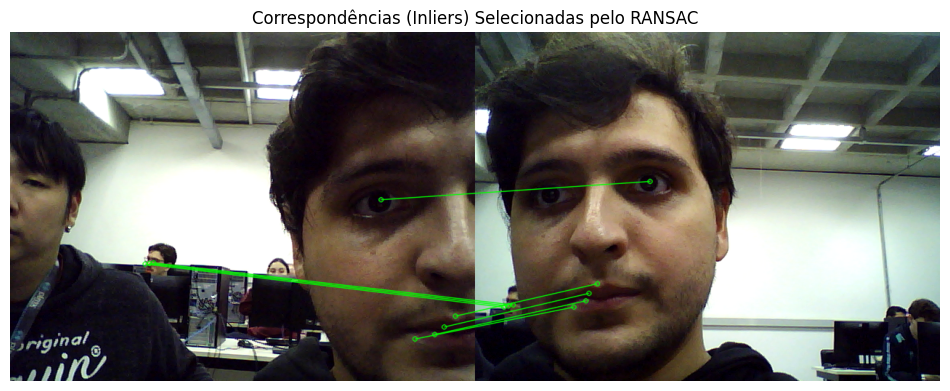

In [5]:
# =====================================================================
# PASSO 3: MÍNIMOS QUADRADOS ROBUSTOS VIA RANSAC
# =====================================================================
# Definimos um limiar de reprojeção de 5 pixels para considerar um inlier
reproj_threshold = 5.0
H_ransac, mask_ransac = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, reproj_threshold)

print("\n--- Matriz de Homografia via RANSAC ---")
print(H_ransac)

# Contagem de Inliers e Outliers
inliers_count = np.sum(mask_ransac)
outliers_count = len(mask_ransac) - inliers_count
print(f"\nResultado RANSAC: {inliers_count} Inliers | {outliers_count} Outliers")

# Visualização das correspondências aceitas pelo RANSAC
img_matches = cv2.drawMatches(img1, kp1, img2, kp2, bons_matches, None, 
                              matchColor=(0, 255, 0), singlePointColor=None, 
                              matchesMask=mask_ransac.ravel().tolist(), flags=2)

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title("Correspondências (Inliers) Selecionadas pelo RANSAC")
plt.axis('off')
plt.show()

**Passo 4 — Mosaico.** Projetamos a imagem 1 no plano da imagem 2 com cada
homografia e comparamos o mosaico por Mínimos Quadrados com o mosaico por
RANSAC.

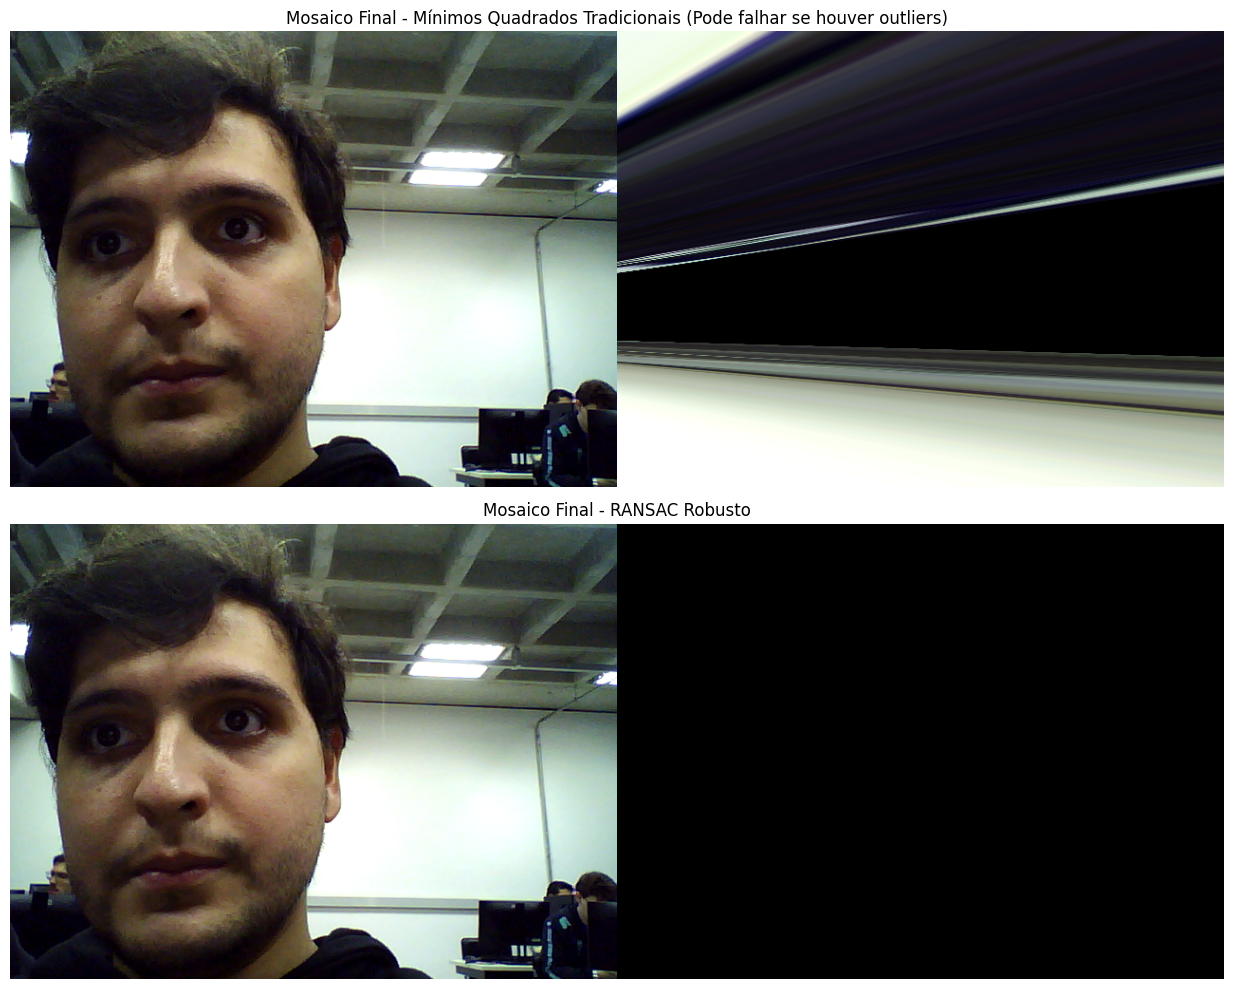

In [6]:
# =====================================================================
# PASSO 4: COSTURA DE IMAGENS (IMAGE STITCHING)
# =====================================================================
# Vamos rotacionar e projetar a Imagem 1 no plano da Imagem 2
width = img1.shape[1] + img2.shape[1]
height = max(img1.shape[0], img2.shape[0])

# Projeção usando Homografia por Mínimos Quadrados
img1_warped_ls = cv2.warpPerspective(img1, H_ls, (width, height))

# Projeção usando Homografia pelo RANSAC
img1_warped_ransac = cv2.warpPerspective(img1, H_ransac, (width, height))

# Criação do Mosaico (colando a imagem 2 por cima da zona de projeção)
mosaico_ls = img1_warped_ls.copy()
mosaico_ls[0:img2.shape[0], 0:img2.shape[1]] = img2

mosaico_ransac = img1_warped_ransac.copy()
mosaico_ransac[0:img2.shape[0], 0:img2.shape[1]] = img2

# Exibição dos resultados comparativos
fig, ax = plt.subplots(2, 1, figsize=(14, 10))
ax[0].imshow(cv2.cvtColor(mosaico_ls, cv2.COLOR_BGR2RGB))
ax[0].set_title("Mosaico Final - Mínimos Quadrados Tradicionais (Pode falhar se houver outliers)")
ax[0].axis('off')

ax[1].imshow(cv2.cvtColor(mosaico_ransac, cv2.COLOR_BGR2RGB))
ax[1].set_title("Mosaico Final - RANSAC Robusto")
ax[1].axis('off')

plt.tight_layout()
plt.show()


**Resultado de (A.1).** Este foi o cenário "difícil" — e justamente por isso é
muito instrutivo. O matching gerou **26 bons casamentos**, mas o RANSAC manteve
apenas **8 inliers** (18 outliers), o que dá uma taxa de outliers altíssima. O
motivo é que **o rosto de uma pessoa não é um plano**: quando as duas câmeras o
veem de ângulos diferentes, há muita variação de profundidade (paralaxe), e a
hipótese de homografia (que vale só para superfícies planas) deixa de valer.

O efeito disso aparece nos dois mosaicos: o de **Mínimos Quadrados** "explode" a
imagem projetada em listras esticadas (os outliers distorceram completamente a
transformação), e o de **RANSAC**, embora descarte os erros, também não consegue
montar um mosaico coerente, porque nem mesmo os inliers respeitam um único plano.
Em resumo: este caso mostra um **limite do método** — homografia + mosaico exige
uma cena predominantemente **planar**, o que motiva o segundo experimento.


### 3.2 Experimento (A.2) — Livro

**Captura das duas webcams.** Mesma lógica do item anterior, agora salvando o par
`objeto_esquerda.png` / `objeto_direito.png`. Desta vez o alvo é a **capa de um
livro** sobre a mesa — uma superfície **plana**, que é o caso ideal para a
homografia.

```python
# Lê 2 webcams e tira foto das duas quando apertamos a tecla 'x'
cap_esq = cv2.VideoCapture(0)   # câmera esquerda
cap_dir = cv2.VideoCapture(1)   # câmera direita

if not cap_esq.isOpened() or not cap_dir.isOpened():
    print("Cannot open camera")
    exit()

while True:
    # captura um quadro de cada câmera
    ret_esq, frame_esq = cap_esq.read()
    ret_dir, frame_dir = cap_dir.read()
    # se alguma leitura falhou, ret é False
    if not ret_esq or not ret_dir:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # mostra cada quadro em sua própria janela
    cv2.imshow('esquerda', frame_esq)
    cv2.imshow('direita', frame_dir)

    key = cv2.waitKey(1)          # lê a tecla apertada
    if key == ord('x'):          # 'x': salva as duas fotos e sai
        cv2.imwrite('objeto_esquerda.png', frame_esq)
        cv2.imwrite('objeto_direito.png', frame_dir)
        print("Fotos salvas como 'objeto_esquerda.png' e 'objeto_direito.png'!")
        break
    elif key == ord('q'):        # 'q': sai sem salvar
        break

cap_esq.release()
cap_dir.release()
cv2.destroyAllWindows()
```

In [7]:
# =====================================================================
# CONFIGURAÇÃO E CARREGAMENTO DAS IMAGENS DO ALUNO
# =====================================================================
# Substitua pelos nomes dos seus próprios arquivos de imagem
path_img1 = 'objeto_esquerda.png' 
path_img2 = 'objeto_direito.png'

img1 = cv2.imread(path_img1)
img2 = cv2.imread(path_img2)

if img1 is None or img2 is None:
    raise FileNotFoundError("Verifique se as imagens próprias foram salvas corretamente no diretório.")

# Conversão para escala de cinza para os extratores de feições
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

**Passo 1 — Detecção e correspondência.**

In [8]:
# =====================================================================
# PASSO 1: DETECÇÃO DE CARACTERÍSTICAS E CORRESPONDÊNCIA (MATCHING)
# =====================================================================
# Utilizaremos o SIFT (Scale-Invariant Feature Transform)
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# Força bruta para encontrar os melhores matches usando a razão de Lowe
bf = cv2.BFMatcher()
matches_brutos = bf.knnMatch(des1, des2, k=2)

# Aplicação do teste de razão de Lowe para filtrar matches muito ambíguos
bons_matches = []
for m, n in matches_brutos:
    if m.distance < 0.75 * n.distance:
        bons_matches.append(m)

# Extração das coordenadas numéricas dos pontos correspondentes
src_pts = np.float32([kp1[m.queryIdx].pt for m in bons_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in bons_matches]).reshape(-1, 1, 2)

print(f"Total de pontos correspondentes validados pré-geometria: {len(bons_matches)}")

Total de pontos correspondentes validados pré-geometria: 122


**Passo 2 — Mínimos Quadrados clássico.**

In [9]:
# =====================================================================
# PASSO 2: ALINHAMENTO 2D VIA MÍNIMOS QUADRADOS TRADICIONAIS (SEM RANSAC)
# =====================================================================
# O método clássico tenta ajustar todos os pontos de uma vez (method=0)
H_ls, status_ls = cv2.findHomography(src_pts, dst_pts, method=0)

print("\n--- Matriz de Homografia via Mínimos Quadrados Clássicos ---")
print(H_ls)



--- Matriz de Homografia via Mínimos Quadrados Clássicos ---
[[-1.10454667e+00 -4.41610103e-01  5.20450633e+02]
 [-5.80962930e-01 -2.78211001e-02  2.24355821e+02]
 [-2.03658289e-03 -9.65356244e-04  1.00000000e+00]]


**Passo 3 — RANSAC** (inliers/outliers e visualização).


--- Matriz de Homografia via RANSAC ---
[[ 6.51024273e-01 -2.66975900e-01  4.26684588e+02]
 [-6.53616471e-02  5.35162058e-01  1.20123684e+02]
 [-5.59019280e-04 -6.12645849e-04  1.00000000e+00]]

Resultado RANSAC: 93 Inliers | 29 Outliers


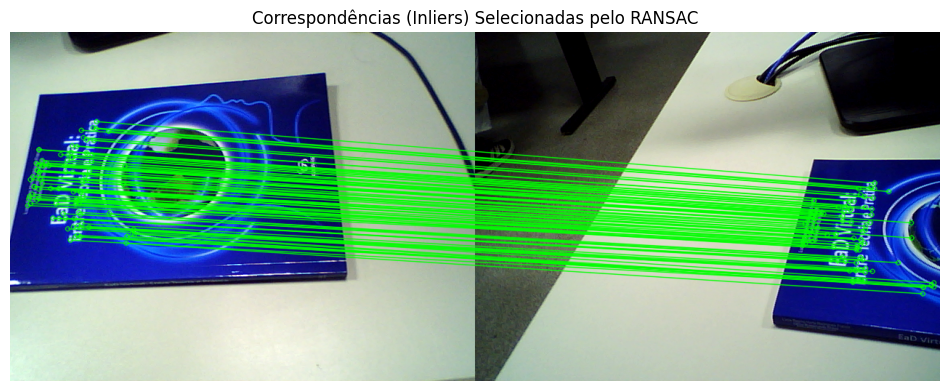

In [10]:
# =====================================================================
# PASSO 3: MÍNIMOS QUADRADOS ROBUSTOS VIA RANSAC
# =====================================================================
# Definimos um limiar de reprojeção de 5 pixels para considerar um inlier
reproj_threshold = 5.0
H_ransac, mask_ransac = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, reproj_threshold)

print("\n--- Matriz de Homografia via RANSAC ---")
print(H_ransac)

# Contagem de Inliers e Outliers
inliers_count = np.sum(mask_ransac)
outliers_count = len(mask_ransac) - inliers_count
print(f"\nResultado RANSAC: {inliers_count} Inliers | {outliers_count} Outliers")

# Visualização das correspondências aceitas pelo RANSAC
img_matches = cv2.drawMatches(img1, kp1, img2, kp2, bons_matches, None, 
                              matchColor=(0, 255, 0), singlePointColor=None, 
                              matchesMask=mask_ransac.ravel().tolist(), flags=2)

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title("Correspondências (Inliers) Selecionadas pelo RANSAC")
plt.axis('off')
plt.show()

**Passo 4 — Mosaico** (LS × RANSAC).

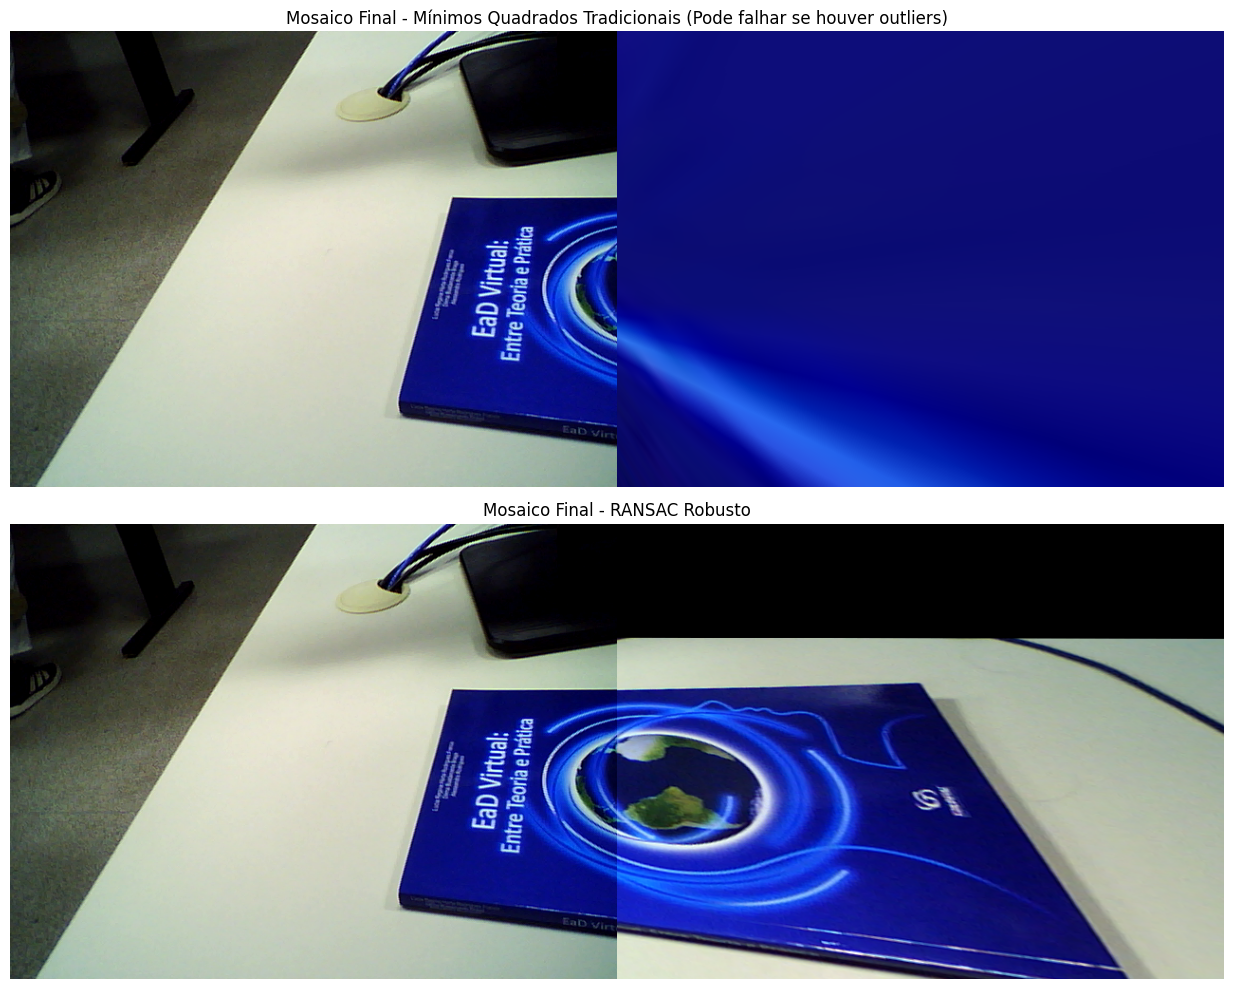

In [11]:
# =====================================================================
# PASSO 4: COSTURA DE IMAGENS (IMAGE STITCHING)
# =====================================================================
# Vamos rotacionar e projetar a Imagem 1 no plano da Imagem 2
width = img1.shape[1] + img2.shape[1]
height = max(img1.shape[0], img2.shape[0])

# Projeção usando Homografia por Mínimos Quadrados
img1_warped_ls = cv2.warpPerspective(img1, H_ls, (width, height))

# Projeção usando Homografia pelo RANSAC
img1_warped_ransac = cv2.warpPerspective(img1, H_ransac, (width, height))

# Criação do Mosaico (colando a imagem 2 por cima da zona de projeção)
mosaico_ls = img1_warped_ls.copy()
mosaico_ls[0:img2.shape[0], 0:img2.shape[1]] = img2

mosaico_ransac = img1_warped_ransac.copy()
mosaico_ransac[0:img2.shape[0], 0:img2.shape[1]] = img2

# Exibição dos resultados comparativos
fig, ax = plt.subplots(2, 1, figsize=(14, 10))
ax[0].imshow(cv2.cvtColor(mosaico_ls, cv2.COLOR_BGR2RGB))
ax[0].set_title("Mosaico Final - Mínimos Quadrados Tradicionais (Pode falhar se houver outliers)")
ax[0].axis('off')

ax[1].imshow(cv2.cvtColor(mosaico_ransac, cv2.COLOR_BGR2RGB))
ax[1].set_title("Mosaico Final - RANSAC Robusto")
ax[1].axis('off')

plt.tight_layout()
plt.show()


**Resultado de (A.2).** Aqui o pipeline funcionou como esperado. O livro,
sendo **plano e cheio de textura** (o título e o desenho da capa geram muitos
pontos SIFT), produziu **122 bons casamentos**, dos quais o RANSAC validou **93
inliers** (29 outliers). A figura de inliers mostra dezenas de linhas verdes
praticamente paralelas, indicando casamentos coerentes.

A comparação dos mosaicos é o ponto alto: no de **Mínimos Quadrados**, os 29
outliers distorceram a projeção e a capa do livro aparece **esticada e ampliada**,
tomando conta de toda a metade direita (claramente errado). Já no de **RANSAC**, a
capa do livro é **reconstruída corretamente** e as duas vistas se encaixam,
formando um mosaico que faz sentido. A diferença entre as duas imagens é a prova
visual de por que a estimação robusta é necessária.


### 3.3 Item (B) — Sobreposição em tempo real (vídeo)

Para o item (B), juntamos todo o pipeline (SIFT → Lowe → LS e RANSAC → mosaico)
em um **laço que roda quadro a quadro** sobre as duas webcams. A cada par de
quadros, o programa calcula as duas homografias e monta dois mosaicos, exibidos
**empilhados** (Mínimos Quadrados em cima, RANSAC embaixo) com o número de matches
e de inliers escritos na tela. Quando há poucos casamentos, um *fallback* mostra
as duas câmeras lado a lado. O resultado é exibido ao vivo e **gravado** em
`saida_mosaico_estereo.avi`. A execução encerra com a tecla **`q`**.


In [ ]:
import cv2
import numpy as np

# ---- Índices das câmeras (ajuste se a 2ª não for 1; veja a célula de diagnóstico) ----
CAM_ESQ = 0   # câmera esquerda -> imagem PROJETADA (faz o papel da img1)
CAM_DIR = 1   # câmera direita  -> plano de REFERÊNCIA (faz o papel da img2)

# No Linux costuma ajudar forçar o backend V4L2:
cap_esq = cv2.VideoCapture(0)   # câmera esquerda
cap_dir = cv2.VideoCapture(1) 

if not cap_esq.isOpened() or not cap_dir.isOpened():
    print("Cannot open camera (confira CAM_ESQ / CAM_DIR)")
    cap_esq.release(); cap_dir.release()
    raise SystemExit

# Dimensões (assumimos que as duas câmeras têm o mesmo tamanho)
W = int(cap_esq.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap_esq.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = 30.0

# O mosaico tem o DOBRO da largura (img1 projetada + img2 colada).
# Empilhamos os 2 métodos -> a altura final também dobra.
mosaico_w, mosaico_h = W * 2, H
saida_w, saida_h = mosaico_w, mosaico_h * 2   # LS em cima, RANSAC embaixo

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('saida_mosaico_estereo.avi', fourcc, fps, (saida_w, saida_h))

# Detector e matcher criados UMA vez (fora do loop), como na referência do SIFT
sift = cv2.SIFT_create()
bf = cv2.BFMatcher()

MIN_MATCHES = 10          # mínimo de bons matches p/ tentar a homografia
REPROJ_THRESHOLD = 5.0    # mesmo limiar de inlier usado nas imagens estáticas


def montar_mosaico(frame_esq, frame_dir, H_matrix, titulo, info=""):
    """Projeta frame_esq (img1) no plano de frame_dir (img2) e cola o mosaico.
    Retorna SEMPRE um quadro de tamanho fixo (mosaico_h, mosaico_w, 3)."""
    canvas = np.zeros((mosaico_h, mosaico_w, 3), dtype=np.uint8)

    if H_matrix is not None:
        # Projeta a câmera esquerda no plano da direita (PASSO 4)
        warp = cv2.warpPerspective(frame_esq, H_matrix, (mosaico_w, mosaico_h))
        canvas[:] = warp
        # Cola a câmera direita por cima da zona de origem
        canvas[0:H, 0:W] = frame_dir
    else:
        # Fallback (poucos matches): mostra as duas câmeras lado a lado
        canvas[0:H, 0:W] = frame_dir
        canvas[0:H, W:2 * W] = frame_esq

    cv2.putText(canvas, titulo, (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    if info:
        cv2.putText(canvas, info, (10, 65),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    return canvas


print("Pressione 'q' na janela de vídeo para encerrar.")

while cap_esq.isOpened() and cap_dir.isOpened():
    ret_esq, frame_esq = cap_esq.read()
    ret_dir, frame_dir = cap_dir.read()
    if not ret_esq or not ret_dir:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # Garante o tamanho esperado (segurança contra variações da webcam)
    frame_esq = cv2.resize(frame_esq, (W, H))
    frame_dir = cv2.resize(frame_dir, (W, H))

    # ---- PASSO 1: SIFT + matching (uma vez por quadro) ----
    gray_esq = cv2.cvtColor(frame_esq, cv2.COLOR_BGR2GRAY)
    gray_dir = cv2.cvtColor(frame_dir, cv2.COLOR_BGR2GRAY)

    kp1, des1 = sift.detectAndCompute(gray_esq, None)
    kp2, des2 = sift.detectAndCompute(gray_dir, None)

    bons_matches = []
    if des1 is not None and des2 is not None and len(kp1) > 2 and len(kp2) > 2:
        matches_brutos = bf.knnMatch(des1, des2, k=2)
        for par in matches_brutos:
            if len(par) == 2:                       # garante os 2 vizinhos
                m, n = par
                if m.distance < 0.75 * n.distance:  # razão de Lowe (igual às imagens)
                    bons_matches.append(m)

    # ---- PASSOS 2 e 3: homografias LS e RANSAC reaproveitando os mesmos pontos ----
    H_ls = None
    H_ransac = None
    n_inliers = 0
    if len(bons_matches) >= MIN_MATCHES:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in bons_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in bons_matches]).reshape(-1, 1, 2)

        # PASSO 2: Mínimos Quadrados clássicos
        H_ls, _ = cv2.findHomography(src_pts, dst_pts, method=0)

        # PASSO 3: RANSAC robusto
        H_ransac, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, REPROJ_THRESHOLD)
        if mask is not None:
            n_inliers = int(np.sum(mask))

    # ---- PASSO 4: monta os dois mosaicos (a "sobreposição") ----
    info_ls = f"Matches: {len(bons_matches)}"
    info_rs = f"Matches: {len(bons_matches)} | Inliers: {n_inliers}"

    mosaico_ls = montar_mosaico(frame_esq, frame_dir, H_ls,
                                "Minimos Quadrados (LS)", info_ls)
    mosaico_rs = montar_mosaico(frame_esq, frame_dir, H_ransac,
                                "RANSAC robusto", info_rs)

    # Empilha verticalmente: LS em cima, RANSAC embaixo
    resultado = np.vstack([mosaico_ls, mosaico_rs])

    out.write(resultado)                                  # grava o quadro
    cv2.imshow('Sobreposicao estereo (LS x RANSAC)', resultado)

    if cv2.waitKey(1) == ord('q'):
        break

cap_esq.release()
cap_dir.release()
out.release()
cv2.destroyAllWindows()


> **Vídeos gerados:** o resultado em tempo real foi salvo como
> **`saida_mosaico_estereo.avi`**, e também registramos uma **gravação de tela**
> da execução ao vivo (`Gravação_de_tela_2026-06-17_22-15-44.webm`). Ambos os
> arquivos acompanham este relatório na pasta da equipe (publicada no GitHub).


## 4. Análise e discussão

A seguir respondemos, com os números obtidos nos experimentos, às questões de
análise propostas no roteiro.

### 4.1 Análise estatística das características (porcentagem de outliers)

Usando a fórmula do roteiro, $\\%\\,\\text{Outliers} = \\left(1 - \\dfrac{\\text{Inliers}}{\\text{Total de Matches}}\\right)\\times 100$:

| Cenário | Total de matches | Inliers (RANSAC) | Outliers | % Outliers |
|---|---|---|---|---|
| (A.1) Pessoa | 26 | 8 | 18 | **69,23 %** |
| (A.2) Livro | 122 | 93 | 29 | **23,77 %** |

No **cenário da pessoa**, a taxa de outliers foi altíssima (≈ 69 %). As
características visuais que justificam isso são, principalmente, a **cena não
planar** (rosto e fundo da sala em profundidades diferentes, gerando paralaxe) e
as **texturas repetitivas do ambiente** — as placas do forro, as luminárias
fluorescentes alinhadas e os monitores ao fundo se parecem entre si, o que produz
muitos **falsos positivos** que o teste de Lowe não consegue descartar e que o
RANSAC acaba rejeitando.

No **cenário do livro**, a taxa caiu para ≈ 24 %. Mesmo sendo um plano bem
texturizado, a capa é **brilhosa/reflexiva** e tem um desenho com simetrias (o
círculo luminoso e o globo), o que ainda gera alguns casamentos ambíguos —
explicando os 29 outliers que sobraram. Ainda assim, a maioria esmagadora dos
pontos é coerente, e por isso o mosaico final ficou correto.

### 4.2 Álgebra linear e homografia (comparação das matrizes)

**Por que $h_{22}$ é normalizado como 1,0?** Porque a homografia é definida **a
menos de um fator de escala**: multiplicar toda a matriz por uma constante resulta
na mesma transformação geométrica. Para remover essa ambiguidade e deixar a
solução única, fixa-se $h_{22} = 1$ — o que reduz os 9 elementos a **8 parâmetros
livres** (8 graus de liberdade). Por isso ambas as matrizes, LS e RANSAC, aparecem
com 1,0 nessa posição.

**Diferença absoluta nos vetores de translação ($h_{02}$ e $h_{12}$):**

| Cenário | $|\\Delta h_{02}|$ (translação horizontal) | $|\\Delta h_{12}|$ (translação vertical) |
|---|---|---|
| (A.2) Livro — caso planar | $|426{,}68 - 520{,}45| = $ **93,77 px** | $|120{,}12 - 224{,}36| = $ **104,23 px** |
| (A.1) Pessoa — caso não planar | $|1209{,}45 - 183{,}59| = $ **1025,86 px** | $|{-}4530{,}22 - 312{,}95| = $ **4843,17 px** |

**Interpretação.** No caso planar do livro, a diferença de translação entre os dois
métodos já é considerável (cerca de 90–100 px): os 29 outliers "puxaram" a solução
de Mínimos Quadrados, deslocando fisicamente para onde a imagem foi projetada — é
por isso que, no mosaico LS, a capa aparece no lugar errado e ampliada. No caso da
pessoa, a distorção é **ordens de grandeza maior** (mais de 1000 px no horizontal
e quase 4900 px no vertical), levando os pixels para muito fora do quadro útil e
produzindo aquelas listras esticadas. Em ambos os casos fica claro o mesmo
princípio: **os outliers contaminam diretamente o vetor de translação estimado por
Mínimos Quadrados**, enquanto o RANSAC, por usar só os inliers, mantém a translação
em valores fisicamente plausíveis.

### 4.3 Análise geométrica e robótica

**Número mínimo de pares de pontos.** A homografia tem **8 graus de liberdade**
(9 elementos com $h_{22}=1$). Como **cada correspondência de ponto fornece 2
equações** independentes (uma para a coordenada $x'$ e outra para $y'$), são
necessários $8 / 2 = $ **4 pares de pontos** para computar uma homografia válida —
desde que não haja 3 pontos colineares (eles precisam estar em "posição geral").
Não por acaso, é exatamente esse o tamanho da amostra que o RANSAC sorteia a cada
iteração.

**Superfície uniforme (robótica móvel).** Se um drone mapeando um terreno plano
focar em uma **superfície completamente uniforme** (sem textura — areia lisa, asfalto
homogêneo, neve), o SIFT **não encontra pontos-chave** distintos. Sem
correspondências suficientes, o sistema para estimar $H$ fica **subdeterminado /
singular**, e a matriz resultante é instável ou simplesmente não pode ser calculada.
Na prática, isso significa que a **navegação baseada em visão (odometria visual)
falha**: o robô "se perde", pois não tem referências para estimar o próprio
movimento. A solução é **fundir** a visão com outros sensores (IMU, GPS, LiDAR,
sensores de fluxo óptico) ou projetar textura/marcadores artificiais no ambiente.

### 4.4 Qualidade do processamento de imagem (artefatos de costura)

**Onde está a emenda.** No mosaico do livro por RANSAC, a emenda fica
aproximadamente **na linha vertical do meio**, onde a imagem da câmera direita foi
colada por cima da imagem esquerda projetada. Nesse ponto nota-se uma **mudança
brusca de iluminação/exposição** (a metade vinda de uma câmera é levemente mais
clara que a da outra) e uma **linha de corte nítida**, além de um leve desalinhamento
nas bordas do livro (indício de pequeno *ghosting*).

**Técnica de pós-processamento (literatura de Szeliski).** Para minimizar essas
discrepâncias de iluminação, a literatura de *image stitching* (Szeliski,
*Computer Vision: Algorithms and Applications*) recomenda substituir a colagem
"dura" por uma **mistura (blending)**. A técnica matemática clássica é o
**multi-band blending** (mistura em múltiplas bandas, via **pirâmides Laplacianas**
de Burt & Adelson): a imagem é decomposta em faixas de frequência, e cada faixa é
combinada com uma largura de transição diferente — as baixas frequências (brilho
geral) são misturadas suavemente em uma região larga, enquanto as altas
frequências (detalhes/bordas) são combinadas em uma faixa estreita. Isso elimina a
linha de corte sem borrar os detalhes. Como complemento específico para diferenças
de exposição entre as câmeras, aplica-se também **compensação de ganho/exposição
(gain compensation)** antes da costura. Alternativas citadas são o *feathering*
(mistura linear/alfa simples) e o *Poisson blending* (mistura no domínio do
gradiente).


## 5. Conclusões

Cumprimos os objetivos do laboratório. Compreendemos, na teoria e na prática, o
**alinhamento de imagens por homografia 2D** e implementamos um **pipeline completo
de mosaico** (SIFT → matching com razão de Lowe → estimação da homografia →
costura), nos dois cenários pedidos e também em vídeo ao vivo.

O aprendizado central veio da comparação entre **Mínimos Quadrados clássico** e
**RANSAC**. Vimos numericamente que os outliers (24 % no livro e 69 % na pessoa)
**distorcem fisicamente** a transformação estimada por Mínimos Quadrados —
chegando a deslocar a translação em mais de mil pixels no caso não planar — enquanto
o RANSAC, por usar apenas os inliers, entrega resultados muito mais coerentes. O
mosaico do livro por RANSAC ficou correto; o de Mínimos Quadrados, distorcido.

O experimento da pessoa, embora "falho" como mosaico, foi tão valioso quanto o do
livro: ele evidenciou que a homografia pressupõe uma cena **planar**, e que
texturas repetitivas e paralaxe são fontes diretas de outliers. Por fim,
consolidamos conceitos importantes — os **8 graus de liberdade** da homografia, o
**mínimo de 4 pares de pontos**, o porquê da normalização $h_{22}=1$ e as técnicas
de **blending** (multi-band, *gain compensation*) para suavizar a emenda do
mosaico. No conjunto, o laboratório deu uma base sólida para aplicações de visão
mais avançadas, como mapeamento robótico e inspeção industrial.


## 6. Referências

1. SZELISKI, R. *Computer Vision: Algorithms and Applications*. 2ª ed. Springer,
   2022. (Cap. de *Image Stitching* — homografia, *multi-band blending* e
   compensação de exposição.)
2. FISCHLER, M. A.; BOLLES, R. C. *Random Sample Consensus (RANSAC): A Paradigm
   for Model Fitting with Applications to Image Analysis and Automated
   Cartography*. Communications of the ACM, v. 24, n. 6, p. 381-395, 1981.
3. LOWE, D. G. *Distinctive Image Features from Scale-Invariant Keypoints*.
   International Journal of Computer Vision, v. 60, n. 2, p. 91-110, 2004.
4. BURT, P. J.; ADELSON, E. H. *A Multiresolution Spline with Application to Image
   Mosaics*. ACM Transactions on Graphics, v. 2, n. 4, p. 217-236, 1983.
5. BROWN, M.; LOWE, D. G. *Automatic Panoramic Image Stitching using Invariant
   Features*. International Journal of Computer Vision, v. 74, p. 59-73, 2007.
6. HARTLEY, R.; ZISSERMAN, A. *Multiple View Geometry in Computer Vision*. 2ª ed.
   Cambridge University Press, 2004.
7. OpenCV — *Feature Matching + Homography to find Objects*.
   https://docs.opencv.org/4.x/d1/de0/tutorial_py_feature_homography.html
8. LearnOpenCV — *Homography Examples using OpenCV*.
   https://learnopencv.com/homography-examples-using-opencv-python-c/
9. GeeksforGeeks — *Image Stitching with OpenCV*.
   https://www.geeksforgeeks.org/computer-vision/image-stitching-with-opencv/
10. PyImageSearch — *OpenCV panorama stitching*.
    https://pyimagesearch.com/2016/01/11/opencv-panorama-stitching/
11. Roteiro do Laboratório 3 — ESZA019 Visão Computacional, UFABC, 2026.2 (v.2).
